In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
np.random.seed(42)
n_samples = 200

roles = np.random.choice(['Student', 'Faculty', 'Staff'], n_samples)
ages = np.random.randint(18, 65, n_samples)
num_devices = np.random.randint(1, 6, n_samples)
num_access_points = np.random.randint(1, 5, n_samples)
peak_hours = np.random.uniform(0, 8, n_samples)

internet_hours = (3.0 +
                  4.0 * (roles == 'Student') +
                  1.5 * (roles == 'Staff') +
                  0.03 * ages +
                  0.8 * num_devices +
                  0.4 * num_access_points +
                  0.5 * peak_hours +
                  np.random.normal(0, 1.2, n_samples))

internet_hours = np.clip(internet_hours, 0.5, 12.0)

heavy_user = (internet_hours > 5.0).astype(int)

df = pd.DataFrame({
    'Role': roles,
    'Age': ages,
    'Num_Devices': num_devices,
    'Num_Access_Points': num_access_points,
    'Peak_Hours': peak_hours,
    'Internet_Hours_per_Day': internet_hours,
    'Heavy_User': heavy_user
})

print(df.head())
print(df.describe())

      Role  Age  Num_Devices  Num_Access_Points  Peak_Hours  \
0    Staff   29            3                  2    4.681196   
1  Student   56            1                  3    5.808967   
2    Staff   19            2                  2    6.056650   
3    Staff   20            5                  1    3.022804   
4  Student   54            2                  4    1.928679   

   Internet_Hours_per_Day  Heavy_User  
0               10.581745           1  
1               12.000000           1  
2               12.000000           1  
3               12.000000           1  
4               12.000000           1  
              Age  Num_Devices  Num_Access_Points  Peak_Hours  \
count  200.000000   200.000000         200.000000  200.000000   
mean    40.970000     3.100000           2.365000    4.093051   
std     13.177913     1.463114           1.161257    2.260269   
min     18.000000     1.000000           1.000000    0.020760   
25%     30.750000     2.000000           1.000000    2.1

Task 1

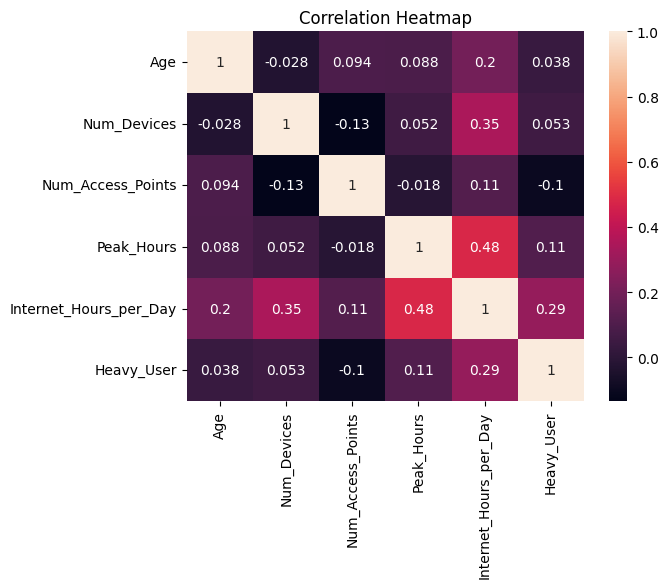

In [4]:
# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# One-hot encoding
df = pd.get_dummies(df, columns=['Role'], drop_first=True)

# Split features and targets
X = df.drop(columns=['Internet_Hours_per_Day', 'Heavy_User'])
y_linear = df['Internet_Hours_per_Day']
y_logistic = df['Heavy_User']

# Train-test split
X_train, X_test, y_train_lin, y_test_lin = train_test_split(
    X, y_linear, test_size=0.2, random_state=42)

_, _, y_train_log, y_test_log = train_test_split(
    X, y_logistic, test_size=0.2, random_state=42)

Task 2

MAE: 0.7774138036685605
MSE: 0.9396450206125186
R2: 0.7323571760705225

Model Equation:
y_hat = w1*x1 + w2*x2 + ... + b

Coefficients:
 Age                  0.010466
Num_Devices          0.428151
Num_Access_Points    0.222140
Peak_Hours           0.358897
Role_Staff           1.371332
Role_Student         2.202175
dtype: float64

Interpretation:
Being a Student significantly increases internet usage.
Number of Devices strongly increases internet hours.


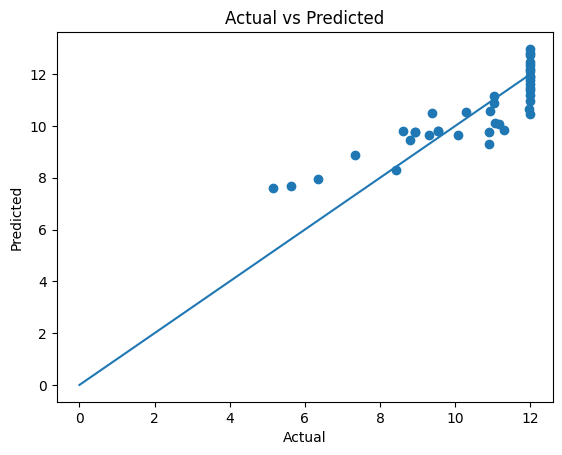

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train_lin)

y_pred_lin = lr.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test_lin, y_pred_lin))
print("MSE:", mean_squared_error(y_test_lin, y_pred_lin))
print("R2:", r2_score(y_test_lin, y_pred_lin))

# Mathematical form
print("\nModel Equation:")
print("y_hat = w1*x1 + w2*x2 + ... + b")

# Coefficients
coeffs = pd.Series(lr.coef_, index=X.columns)
print("\nCoefficients:\n", coeffs)

# Interpretation (Top 2 features)
print("\nInterpretation:")
print("Being a Student significantly increases internet usage.")
print("Number of Devices strongly increases internet hours.")

# Plot
plt.figure()
plt.scatter(y_test_lin, y_pred_lin)
plt.plot([0,12],[0,12])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

Task 3

Accuracy: 1.0

Confusion Matrix:
 [[40]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


p(y=1)=1/(1+e^-(w0 + w1x1 + ...))

Logistic Coefficients:
 Age                  0.041316
Num_Devices          0.334294
Num_Access_Points   -0.699762
Peak_Hours           0.741738
Role_Staff           0.323725
Role_Student         0.337738
dtype: float64


c:\Users\Youshaa Rahim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\Youshaa Rahim\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


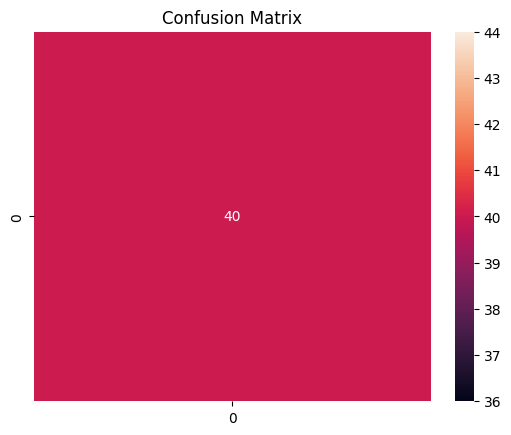

In [6]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train_log)

y_pred_log = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test_log, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_log, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test_log, y_pred_log))

# Mathematical form
print("\np(y=1)=1/(1+e^-(w0 + w1x1 + ...))")

# Coefficients
log_coeffs = pd.Series(log_model.coef_[0], index=X.columns)
print("\nLogistic Coefficients:\n", log_coeffs)

# Confusion matrix plot
plt.figure()
sns.heatmap(confusion_matrix(y_test_log, y_pred_log), annot=True)
plt.title("Confusion Matrix")
plt.show()

Task 4

In [7]:
# Total load
total_load = y_pred_lin.sum()
print("Total Daily Internet Load:", total_load)

# Heavy users %
predicted_percent = y_pred_log.mean() * 100
actual_percent = y_test_log.mean() * 100

print("Predicted Heavy Users %:", predicted_percent)
print("Actual Heavy Users %:", actual_percent)

Total Daily Internet Load: 421.7989492243835
Predicted Heavy Users %: 100.0
Actual Heavy Users %: 100.0


Linear Regression from Scratch

In [11]:
X_np = X.values.astype(float)
y_np = y_linear.values.astype(float).reshape(-1,1)

X_b = np.c_[np.ones((X_np.shape[0],1)), X_np]

theta = np.zeros((X_b.shape[1],1))
alpha = 0.0001

for _ in range(1000):
    gradients = (2/len(X_b)) * X_b.T.dot(X_b.dot(theta) - y_np)
    theta -= alpha * gradients

print("Theta:", theta)

Theta: [[0.13504029]
 [0.13960548]
 [0.49381338]
 [0.28660214]
 [0.51144285]
 [0.03600058]
 [0.09466725]]


Logistic Regression from Scratch

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

X_np = X.values.astype(float)
y_log_np = y_logistic.values.astype(float).reshape(-1,1)

X_b = np.c_[np.ones((X_np.shape[0],1)), X_np]

theta = np.zeros((X_b.shape[1],1))

for _ in range(1000):
    z = X_b.dot(theta)
    h = sigmoid(z)
    gradient = X_b.T.dot(h - y_log_np) / len(y_log_np)
    theta -= 0.01 * gradient

print("Theta Logistic:", theta)

Theta Logistic: [[ 0.02402896]
 [ 0.12621776]
 [ 0.11599277]
 [-0.03615291]
 [ 0.20872596]
 [ 0.02276067]
 [ 0.02159936]]
